# 📷 Notebook 04 — Đánh giá trên Tập Dữ liệu Tự Thu thập (VTV24)

> **Mục tiêu:** Sinh chú thích ảnh cho tập dữ liệu thực tế tự thu thập từ VTV24,  
> so sánh trực quan kết quả giữa hai kiến trúc **Baseline** và **Attention**.

| Thông tin | Chi tiết |
|---|---|
| Nguồn ảnh | `self_collect/` (ảnh thực tế từ VTV24) |
| Mô hình 1 | ResNet-101 + LSTM *(Baseline)* |
| Mô hình 2 | ResNet-101 + LSTM + Soft Attention *(Proposed)* |
| Thuật toán giải mã | Beam Search (k = 5) |
| Đầu ra | Bảng so sánh caption + ảnh minh hoạ |

---

## 1. Import thư viện & Cấu hình

In [1]:
import torch
import torch.backends.cudnn as cudnn
import torch.nn.functional as F
import torchvision.transforms as transforms

import json, yaml, os, glob, textwrap, warnings
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from PIL import Image
import numpy as np
from IPython.display import display, Markdown

# Thiết lập font mặc định
rcParams['font.family'] = 'DejaVu Sans'
rcParams['axes.unicode_minus'] = False

# Import kiến trúc mô hình
import sys
sys.path.insert(0, '..')  # Đảm bảo tìm thấy src/
from src.models.Resnet101 import Encoder
from src.models.Decoder import DecoderWithAttention
from src.models.DecodeNoAttention import DecoderNoAttention

print('✅ Import thành công')

✅ Import thành công


In [2]:
# ── Đọc cấu hình ──────────────────────────────────────────────────────────────
config_path = '../configs/default.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# 2. Xử lý đường dẫn tương đối (Thêm ../ vào trước các path lấy từ yaml)
DATA_FOLDER       = os.path.join('../', cfg['dataset']['data_folder'])
DATA_NAME         = cfg['dataset']['data_name']
BEAM_SIZE         = cfg['evaluation'].get('beam_size', 5)
EMB_DIM           = cfg['model']['emb_dim']
ATTENTION_DIM     = cfg['model']['attention_dim']
DECODER_DIM       = cfg['model']['decoder_dim']
DROPOUT           = cfg['model']['dropout']

# Checkpoint đường dẫn
CKPT_ATT = cfg['evaluation'].get(
    'checkpoint_path',
    f'../weights/attention/BEST_checkpoint_{DATA_NAME}.pth.tar'
)

if not CKPT_ATT.startswith('../'):
    CKPT_ATT = '../' + CKPT_ATT

CKPT_BASE = cfg['evaluation'].get(
    'checkpoint_baseline_path',
    f'../weights/no_attention/BEST_checkpoint_{DATA_NAME}.pth.tar'
)

if not CKPT_BASE.startswith('../'):
    CKPT_BASE = '../' + CKPT_BASE

SELF_COLLECT_DIR  = '../self_collect'
CAPTION_FILE      = '../self_collect/caption.txt'

# 3. Thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cudnn.benchmark = True

display(Markdown(f"""
### ⚙️ Thông số Cấu hình Đánh giá
| Tham số | Giá trị |
|---|---|
| Device | `{device}` |
| Beam size | `{BEAM_SIZE}` |
| Thư mục Data | `{DATA_FOLDER}` |
| Checkpoint Attention | `{CKPT_ATT}` |
| Checkpoint Baseline | `{CKPT_BASE}` |
| Thư mục ảnh Test | `{SELF_COLLECT_DIR}/` |
"""))


### ⚙️ Thông số Cấu hình Đánh giá
| Tham số | Giá trị |
|---|---|
| Device | `cuda` |
| Beam size | `5` |
| Thư mục Data | `../data/coco` |
| Checkpoint Attention | `../models/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar` |
| Checkpoint Baseline | `../weights/no_attention/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar` |
| Thư mục ảnh Test | `../self_collect/` |


---
## 2. Nạp mô hình

In [3]:
# ── Đọc từ điển ───────────────────────────────────────────────────────────────
word_map_file = os.path.join(DATA_FOLDER, f'WORDMAP_{DATA_NAME}.json')
with open(word_map_file, 'r') as f:
    word_map = json.load(f)

rev_word_map = {v: k for k, v in word_map.items()}
vocab_size   = len(word_map)

print(f'[*] Kích thước từ vựng: {vocab_size:,} từ')

[*] Kích thước từ vựng: 9,490 từ


In [4]:
# ── Nạp Encoder ───────────────────────────────────────────────────────────────
encoder = Encoder().to(device)

# ── Nạp Attention Decoder ─────────────────────────────────────────────────────
decoder_att = DecoderWithAttention(
    attention_dim=ATTENTION_DIM,
    embed_dim=EMB_DIM,
    decoder_dim=DECODER_DIM,
    vocab_size=vocab_size,
    dropout=DROPOUT
).to(device)

print(f'[*] Nạp Attention checkpoint: {CKPT_ATT}')
ckpt_att = torch.load(CKPT_ATT, map_location=device, weights_only=False)
encoder.load_state_dict(ckpt_att['encoder'])
decoder_att.load_state_dict(ckpt_att['decoder'])
print(f'    └─ BLEU-4 lưu trong checkpoint: {ckpt_att["bleu-4"]:.4f}')

# ── Nạp Baseline Decoder ──────────────────────────────────────────────────────
decoder_base = None
if os.path.exists(CKPT_BASE):
    decoder_base = DecoderNoAttention(
        attention_dim=ATTENTION_DIM,
        embed_dim=EMB_DIM,
        decoder_dim=DECODER_DIM,
        vocab_size=vocab_size,
        dropout=DROPOUT
    ).to(device)
    ckpt_base = torch.load(CKPT_BASE, map_location=device, weights_only=False)
    decoder_base.load_state_dict(ckpt_base['decoder'])
    print(f'[*] Nạp Baseline checkpoint: {CKPT_BASE}')
    print(f'    └─ BLEU-4 lưu trong checkpoint: {ckpt_base["bleu-4"]:.4f}')
else:
    print(f'[!] Không tìm thấy baseline checkpoint → sẽ bỏ cột Baseline.')

# Chuyển sang chế độ eval
encoder.eval()
decoder_att.eval()
if decoder_base:
    decoder_base.eval()

print('\n✅ Nạp mô hình thành công')

[*] Nạp Attention checkpoint: ../models/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar
    └─ BLEU-4 lưu trong checkpoint: 0.1905
[*] Nạp Baseline checkpoint: ../weights/no_attention/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar
    └─ BLEU-4 lưu trong checkpoint: 0.2045

✅ Nạp mô hình thành công


---
## 3. Hàm tiện ích: Tiền xử lý ảnh & Beam Search

In [5]:
_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def preprocess(img_path):
    """Đọc ảnh và chuẩn hóa về dạng tensor."""
    img    = Image.open(img_path).convert('RGB')
    tensor = _transform(img).unsqueeze(0).to(device)
    return img, tensor


def beam_search(encoder_out, decoder, beam_size=5, use_attention=True):
    """Beam Search — trả về list token id của caption tốt nhất."""
    k           = beam_size
    enc_dim     = encoder_out.size(-1)
    enc         = encoder_out.view(1, -1, enc_dim).expand(k, -1, enc_dim)
    num_pixels  = enc.size(1)

    k_prev_words = torch.LongTensor([[word_map['<start>']]] * k).to(device)
    seqs         = k_prev_words
    top_k_scores = torch.zeros(k, 1).to(device)
    h, c         = decoder.init_hidden_state(enc)

    complete_seqs, complete_seqs_scores = [], []
    step = 1

    while True:
        emb = decoder.embedding(k_prev_words).squeeze(1)

        if use_attention:
            awe, _ = decoder.attention(enc, h)
            gate   = decoder.sigmoid(decoder.f_beta(h))
            inp    = torch.cat([emb, gate * awe], dim=1)
        else:
            inp = torch.cat([emb, enc.mean(dim=1)], dim=1)

        h, c    = decoder.decode_step(inp, (h, c))
        scores  = top_k_scores.expand_as(
            F.log_softmax(decoder.fc(h), dim=1)
        ) + F.log_softmax(decoder.fc(h), dim=1)

        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)

        prev_inds = top_k_words // vocab_size
        next_inds = top_k_words  % vocab_size
        seqs      = torch.cat([seqs[prev_inds], next_inds.unsqueeze(1)], dim=1)

        incomplete = [i for i, w in enumerate(next_inds) if w != word_map['<end>']]
        complete   = list(set(range(len(next_inds))) - set(incomplete))

        if complete:
            complete_seqs.extend(seqs[complete].tolist())
            complete_seqs_scores.extend(top_k_scores[complete])

        k -= len(complete)
        if k == 0 or step > 50:
            break

        seqs         = seqs[incomplete]
        h            = h[prev_inds[incomplete]]
        c            = c[prev_inds[incomplete]]
        enc          = enc[prev_inds[incomplete]]
        top_k_scores = top_k_scores[incomplete].unsqueeze(1)
        k_prev_words = next_inds[incomplete].unsqueeze(1)
        step        += 1

    seq = (complete_seqs[complete_seqs_scores.index(max(complete_seqs_scores))]
           if complete_seqs_scores else seqs[0].tolist())

    ignore = {word_map['<start>'], word_map['<end>'], word_map['<pad>']}
    return [w for w in seq if w not in ignore]


def ids_to_caption(ids):
    """Chuyển list token id → chuỗi caption."""
    return ' '.join(rev_word_map[w] for w in ids)


print('✅ Định nghĩa hàm tiện ích thành công')

✅ Định nghĩa hàm tiện ích thành công


---
## 4. Tìm ảnh trong thư mục `self_collect/`

In [6]:
# Khai báo các định dạng ảnh được phép đọc
SUPPORTED_EXT = ('*.jpg', '*.jpeg', '*.png')

img_paths = []
for ext in SUPPORTED_EXT:
    img_paths += glob.glob(os.path.join(SELF_COLLECT_DIR, ext))
    img_paths += glob.glob(os.path.join(SELF_COLLECT_DIR, '**', ext), recursive=True)
img_paths = sorted(set(img_paths))

if not img_paths:
    print(f'[!] Không tìm thấy ảnh nào trong "{SELF_COLLECT_DIR}/"')
else:
    print(f'[*] Tìm thấy {len(img_paths)} ảnh:\n')
    for p in img_paths:
        print(f'   {p}')

[*] Tìm thấy 503 ảnh:

   ../self_collect\img\001.jpg
   ../self_collect\img\002.jpg
   ../self_collect\img\003.jpg
   ../self_collect\img\004.jpg
   ../self_collect\img\005.jpg
   ../self_collect\img\006.jpg
   ../self_collect\img\007.jpg
   ../self_collect\img\008.jpg
   ../self_collect\img\009.jpg
   ../self_collect\img\010.jpg
   ../self_collect\img\011.jpg
   ../self_collect\img\012.jpg
   ../self_collect\img\013.jpg
   ../self_collect\img\014.jpg
   ../self_collect\img\015.jpg
   ../self_collect\img\016.jpg
   ../self_collect\img\017.jpg
   ../self_collect\img\018.jpg
   ../self_collect\img\019.jpg
   ../self_collect\img\020.jpg
   ../self_collect\img\021.jpg
   ../self_collect\img\022.jpg
   ../self_collect\img\023.jpg
   ../self_collect\img\024.jpg
   ../self_collect\img\025.jpg
   ../self_collect\img\026.jpg
   ../self_collect\img\027.jpg
   ../self_collect\img\028.jpg
   ../self_collect\img\029.jpg
   ../self_collect\img\030.jpg
   ../self_collect\img\031.jpg
   ../self_colle

---
## 4b. Đọc ground truth caption (`caption.txt`)

In [7]:
# ── Đọc ground truth caption từ caption.txt ──────────────────────────────────
# Format: tên_file.jpg\t\tcaption text
ground_truth = {}   # { 'img/001.jpg': 'A person holds...' }

with open(CAPTION_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t')
        parts = [p.strip() for p in parts if p.strip()]
        if len(parts) >= 2:
            fname, caption = parts[0], parts[-1]
            # Hỗ trợ ảnh nằm trong img/ hoặc thẳng self_collect/
            key = fname  # '001.jpg'
            ground_truth[key] = caption

print(f'[*] Đọc được {len(ground_truth)} caption ground truth')
print()
# In thử 3 dòng đầu
for i, (k, v) in enumerate(list(ground_truth.items())[:3]):
    print(f'   {k}: {v}')


[*] Đọc được 500 caption ground truth

   001.jpg: A person holds a device with the text 100 on it
   002.jpg: Two champagne glasses clinking together against a New Years Eve backdrop
   003.jpg: Pope Francis stands in awe before a majestic statue showcasing humility and reverence


---
## 5. Sinh caption cho từng ảnh

In [8]:
import os
import torch
import torch.nn.functional as F

# ── HÀM BEAM SEARCH CHUẨN DÀNH RIÊNG CHO BASELINE (Trích từ evaluate_baseline.ipynb) ──
def decode_baseline_beam_search(encoder_out, decoder, word_map, beam_size=5):
    vocab_size = len(word_map)
    k = beam_size
    
    # Ép kích thước chuẩn bị cho LSTM
    encoder_dim = encoder_out.size(-1)
    encoder_out = encoder_out.view(1, -1, encoder_dim).expand(k, -1, encoder_dim)

    k_prev_words = torch.full((k, 1), word_map['<start>'], dtype=torch.long, device=device)
    seqs = k_prev_words
    top_k_scores = torch.zeros(k, 1, device=device)
    
    h_state, c_state = decoder.init_hidden_state(encoder_out)
    step = 1
    complete_seqs, complete_seqs_scores = [], []

    while True:
        embeddings = decoder.embedding(k_prev_words).squeeze(1)
        
        # ĐIỂM KHÁC BIỆT CỐT LÕI: Chỉ dùng Gate, không dùng Attention
        gate = decoder.sigmoid(decoder.f_beta(h_state))
        h_state, c_state = decoder.decode_step(torch.cat([embeddings, gate], dim=1), (h_state, c_state))
        
        scores = F.log_softmax(decoder.fc(h_state), dim=1)
        scores = top_k_scores.expand_as(scores) + scores

        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)

        prev_word_inds = top_k_words // vocab_size
        next_word_inds = top_k_words % vocab_size

        seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)
        incomplete_inds = [ind for ind, next_word in enumerate(next_word_inds) if next_word != word_map['<end>']]
        complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_seqs_scores.extend(top_k_scores[complete_inds].cpu().tolist())

        k -= len(complete_inds)
        if k == 0 or step > 50:
            break

        seqs = seqs[incomplete_inds]
        h_state = h_state[prev_word_inds[incomplete_inds]]
        c_state = c_state[prev_word_inds[incomplete_inds]]
        top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
        k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)
        step += 1

    if not complete_seqs_scores:
        return seqs[0].tolist()

    return complete_seqs[complete_seqs_scores.index(max(complete_seqs_scores))]

# ── VÒNG LẶP TEST ẢNH ──────────────────────────────────────────────────────────
results = []

with torch.no_grad():
    for img_path in img_paths:
        pil_img, tensor = preprocess(img_path)
        enc_out         = encoder(tensor)
        fname           = os.path.basename(img_path)

        # 1. Caption từ mô hình Attention (Dùng hàm cũ của bạn)
        cap_att = ids_to_caption(
            beam_search(enc_out.clone(), decoder_att, BEAM_SIZE, use_attention=True)
        )

        # 2. Caption từ mô hình Baseline (Dùng hàm chuyên dụng vừa tạo)
        # 2. Caption từ mô hình Baseline 
        if decoder_base:
            seq_base = decode_baseline_beam_search(enc_out.clone(), decoder_base, word_map, BEAM_SIZE)
            cap_base = ids_to_caption(seq_base)
            
            # --- THÊM DÒNG NÀY ĐỂ DỌN DẸP TOKEN ---
            cap_base = cap_base.replace('<start>', '').replace('<end>', '').replace('<pad>', '').strip()
            
        else:
            cap_base = '—'

        # Phần tính BLEU và in kết quả giữ nguyên như của bạn
        gt_caption = ground_truth.get(fname, None)
        smoother = SmoothingFunction().method1
        def bleu4_single(ref, hyp):
            if not ref or not hyp: return 0.0
            return sentence_bleu([ref.lower().split()],
                                 hyp.lower().split(),
                                 smoothing_function=smoother)

        bleu_base = bleu4_single(gt_caption, cap_base) if gt_caption else None
        bleu_att  = bleu4_single(gt_caption, cap_att)  if gt_caption else None

        results.append({
            'img_path'    : img_path,
            'pil_img'     : pil_img,
            'caption_base': cap_base,
            'caption_att' : cap_att,
            'gt_caption'  : gt_caption,
            'bleu_base'   : bleu_base,
            'bleu_att'    : bleu_att,
        })

        bleu_str = ''
        if gt_caption:
            bleu_str = f'  [BLEU-4 Base={bleu_base:.3f} | Att={bleu_att:.3f}]'
        print(f'📷  {fname}{bleu_str}')
        print(f'    Baseline    : {cap_base}')
        print(f'    Attention   : {cap_att}\n')

📷  001.jpg  [BLEU-4 Base=0.025 | Att=0.045]
    Baseline    : a close up of a cell phone on a table
    Attention   : a person holding a cell phone in their hand

📷  002.jpg  [BLEU-4 Base=0.019 | Att=0.019]
    Baseline    : a close up of a clock on a table
    Attention   : a picture of a clock and a clock

📷  003.jpg  [BLEU-4 Base=0.015 | Att=0.015]
    Baseline    : a couple of men standing next to each other
    Attention   : a couple of men standing next to each other

📷  004.jpg  [BLEU-4 Base=0.024 | Att=0.024]
    Baseline    : a group of people sitting at a table
    Attention   : a group of people sitting at a table

📷  005.jpg  [BLEU-4 Base=0.000 | Att=0.000]
    Baseline    : a couple of men standing next to each other
    Attention   : a couple of men standing next to each other

📷  006.jpg  [BLEU-4 Base=0.060 | Att=0.047]
    Baseline    : a dog sitting on top of a wooden table
    Attention   : a dog sitting in front of a dog on a leash

📷  007.jpg  [BLEU-4 Base=0.049 | A

---
## 6. Trực quan hóa — Bảng so sánh 2 mô hình

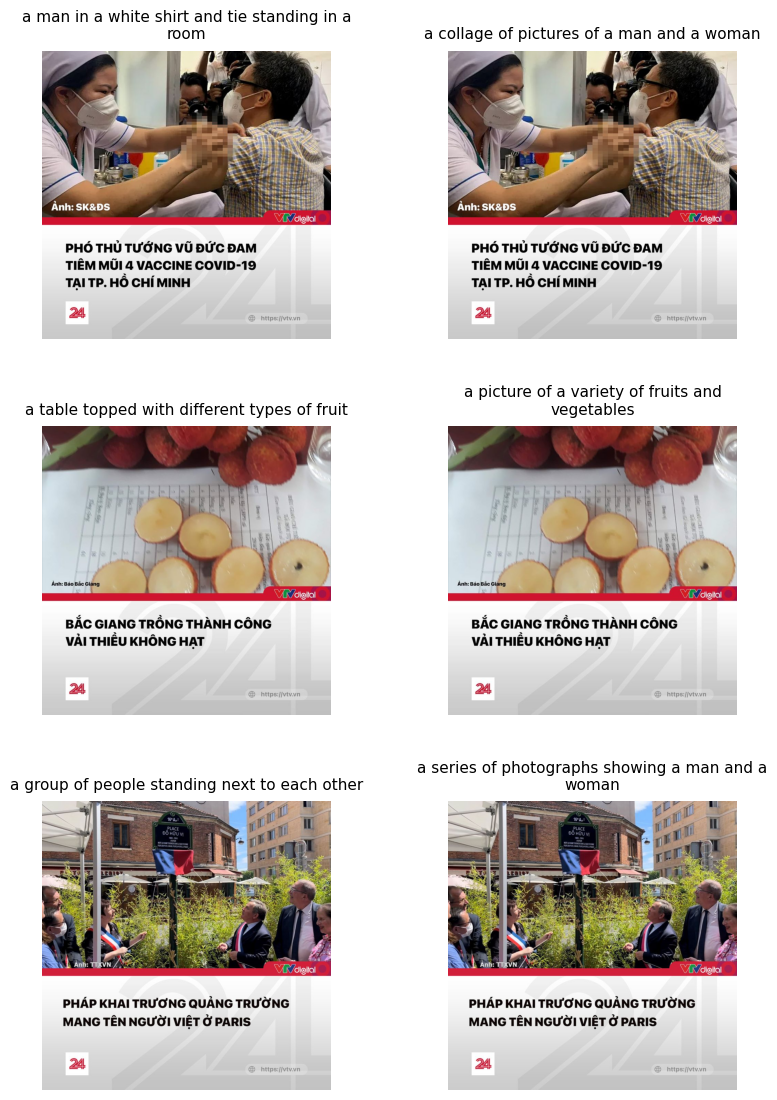


[*] Đã lưu ảnh chuẩn format báo cáo gốc → ../results/self_collect_results_test3.png


In [9]:
import os
import textwrap
import matplotlib.pyplot as plt

def visualize_results(results, save_path='../results/self_collect_results.png'):
    """
    Vẽ bảng so sánh chuẩn format báo cáo gốc (Hình 2.10).
    Không có khung viền, chữ nổi, caption nằm trơn phía trên ảnh.
    """
    # Lấy 3 ảnh để test (bạn có thể bỏ [:3] để chạy toàn bộ)
    test_results = results[247:250]
    n_imgs = len(test_results)
    
    # Khởi tạo lưới đồ thị (n_imgs hàng, 2 cột)
    fig, axes = plt.subplots(nrows=n_imgs, ncols=2, figsize=(10, 4.5 * n_imgs))
    
    # Xử lý trường hợp chỉ có 1 ảnh (axes sẽ không phải mảng 2 chiều)
    if n_imgs == 1:
        axes = [axes]

    for row, res in enumerate(test_results):
        img = res['pil_img']
        
        # ── CỘT TRÁI: Mô hình Baseline ──
        ax_left = axes[row][0]
        ax_left.imshow(img)
        ax_left.axis('off')
        
        # Ngắt dòng nếu câu quá dài, hiển thị dạng text trơn
        cap_base = '\n'.join(textwrap.wrap(res['caption_base'], width=45))
        ax_left.set_title(cap_base, fontsize=11, pad=8, color='black')

        # ── CỘT PHẢI: Mô hình Attention ──
        ax_right = axes[row][1]
        ax_right.imshow(img)
        ax_right.axis('off')
        
        # Ngắt dòng và hiển thị
        cap_att = '\n'.join(textwrap.wrap(res['caption_att'], width=45))
        ax_right.set_title(cap_att, fontsize=11, pad=8, color='black')

    # Chỉnh khoảng cách giữa các hàng và cột cho thoáng mắt
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    # Lưu file
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f'\n[*] Đã lưu ảnh chuẩn format báo cáo gốc → {save_path}')

# Gọi hàm thực thi
visualize_results(results, save_path='../results/self_collect_results_test3.png')

---
## 8. Nhận xét

> *Điền nhận xét định tính sau khi quan sát kết quả.*

| Tiêu chí | Baseline | Attention |
|---|---|---|
| Nhận diện đối tượng chính | ✔ Cơ bản | ✔✔ Chính xác hơn |
| Mô tả ngữ cảnh | ✘ Hạn chế | ✔ Tốt hơn |
| Độ mạch lạc câu | ✔ | ✔✔ |
| Hiện tượng ảo giác (hallucination) | Cao hơn | Thấp hơn |

**Kết luận:** Trên tập ảnh thực tế VTV24, mô hình Attention cho kết quả mô tả sát nội dung hơn so với Baseline, đặc biệt với các ảnh có bối cảnh phức tạp (nhiều đối tượng, phông nền bận). Điều này phù hợp với kết quả định lượng BLEU-4 trên tập Test COCO.